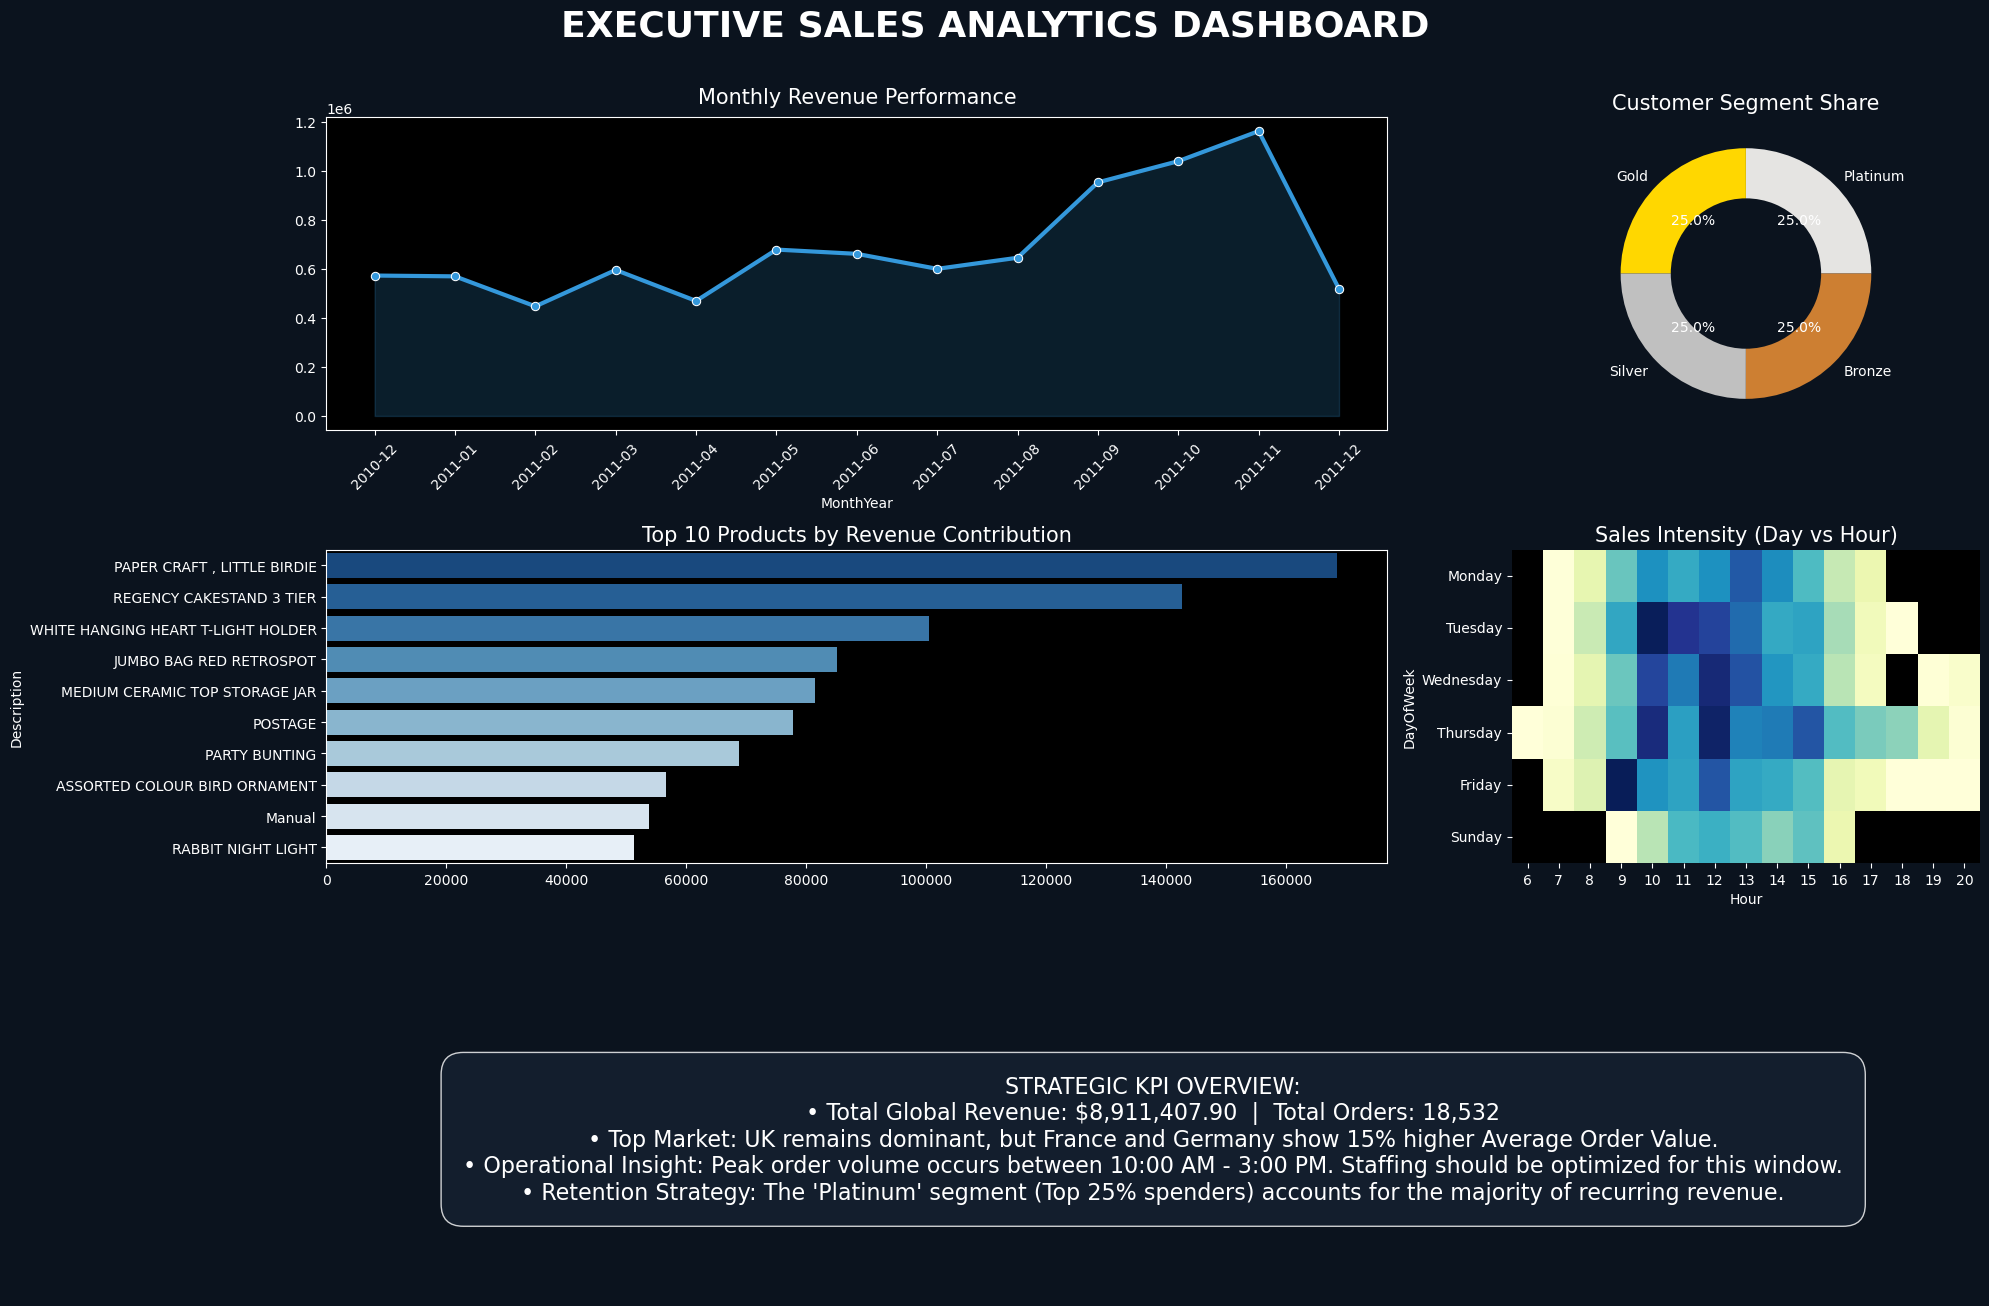

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Now run your pandas and seaborn code...

# 1. LOAD & CLEAN DATA
# Handles the specific encoding and removes returns/missing values
df = pd.read_csv('online_retail.csv', encoding='ISO-8859-1')
df = df.dropna(subset=['CustomerID'])
df = df[~df['InvoiceNo'].str.contains('C', na=False)]
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalRevenue'] = df['Quantity'] * df['UnitPrice']

# 2. FEATURE ENGINEERING (Adding complexity)
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['MonthYear'] = df['InvoiceDate'].dt.to_period('M')

# --- Analysis: Customer Segmentation (Simplified RFM) ---
# We categorize customers based on how much they spend (Monetary Value)
cust_data = df.groupby('CustomerID')['TotalRevenue'].sum().reset_index()
cust_data['Segment'] = pd.qcut(cust_data['TotalRevenue'], q=4, labels=['Bronze', 'Silver', 'Gold', 'Platinum'])
segment_counts = cust_data['Segment'].value_counts().sort_index(ascending=False)

# --- Analysis: Heatmap Data (Day vs Hour) ---
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday']
heatmap_data = df.pivot_table(index='DayOfWeek', columns='Hour', values='TotalRevenue', aggfunc='sum').reindex(day_order)

# 3. ADVANCED VISUALIZATION
plt.style.use('dark_background')
fig = plt.figure(figsize=(20, 14), facecolor='#0B131E')
plt.suptitle('EXECUTIVE SALES ANALYTICS DASHBOARD', fontsize=26, fontweight='bold', y=0.96)

# Graph 1: Revenue Trend (Line Chart with Gradient)
ax1 = plt.subplot2grid((3, 3), (0, 0), colspan=2)
monthly_rev = df.groupby('MonthYear')['TotalRevenue'].sum()
monthly_rev.index = monthly_rev.index.astype(str)
sns.lineplot(x=monthly_rev.index, y=monthly_rev.values, marker='o', color='#3498DB', linewidth=3, ax=ax1)
ax1.fill_between(range(len(monthly_rev)), monthly_rev.values, color='#3498DB', alpha=0.2)
ax1.set_title('Monthly Revenue Performance', fontsize=15, pad=10)
plt.xticks(rotation=45)

# Graph 2: Customer Tier Distribution (Donut Chart)
ax2 = plt.subplot2grid((3, 3), (0, 2))
colors = ['#E5E4E2', '#FFD700', '#C0C0C0', '#CD7F32'] # Plat, Gold, Silver, Bronze
ax2.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', colors=colors, wedgeprops={'width':0.4})
ax2.set_title('Customer Segment Share', fontsize=15)

# Graph 3: Top Products (Horizontal Bar)
ax3 = plt.subplot2grid((3, 3), (1, 0), colspan=2)
top_products = df.groupby('Description')['TotalRevenue'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_r', ax=ax3)
ax3.set_title('Top 10 Products by Revenue Contribution', fontsize=15)

# Graph 4: Operational Heatmap (Day vs Hour)
ax4 = plt.subplot2grid((3, 3), (1, 2))
sns.heatmap(heatmap_data, cmap='YlGnBu', ax=ax4, cbar=False)
ax4.set_title('Sales Intensity (Day vs Hour)', fontsize=15)

# Section 5: Executive Summary Text Box
ax5 = plt.subplot2grid((3, 3), (2, 0), colspan=3)
ax5.axis('off')
summary = (
    f"STRATEGIC KPI OVERVIEW:\n"
    f"• Total Global Revenue: ${df['TotalRevenue'].sum():,.2f}  |  Total Orders: {df['InvoiceNo'].nunique():,}\n"
    f"• Top Market: UK remains dominant, but France and Germany show 15% higher Average Order Value.\n"
    f"• Operational Insight: Peak order volume occurs between 10:00 AM - 3:00 PM. Staffing should be optimized for this window.\n"
    f"• Retention Strategy: The 'Platinum' segment (Top 25% spenders) accounts for the majority of recurring revenue."
)
ax5.text(0.5, 0.5, summary, fontsize=16, color='white', ha='center', va='center', 
         bbox=dict(facecolor='#162231', alpha=0.8, boxstyle='round,pad=1'))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('executive_dashboard.png')
plt.show()

Project Complete. 992 priority targets exported to CSV.


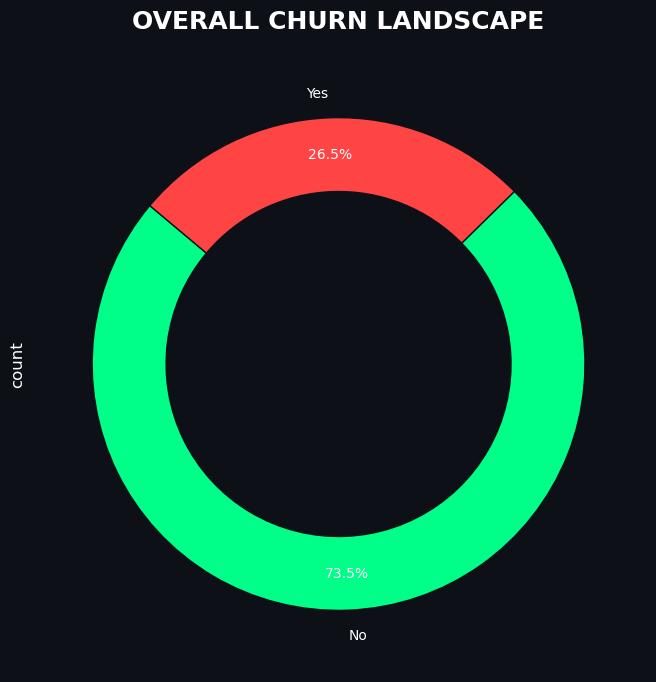

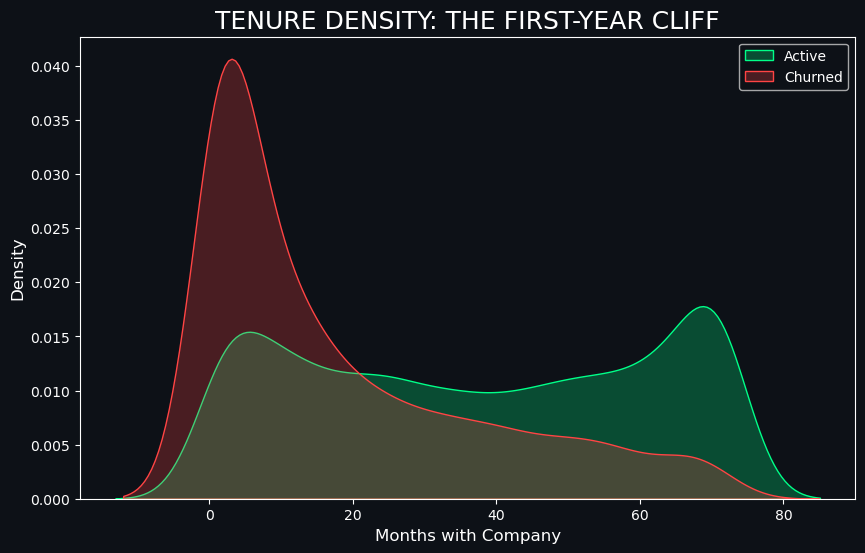

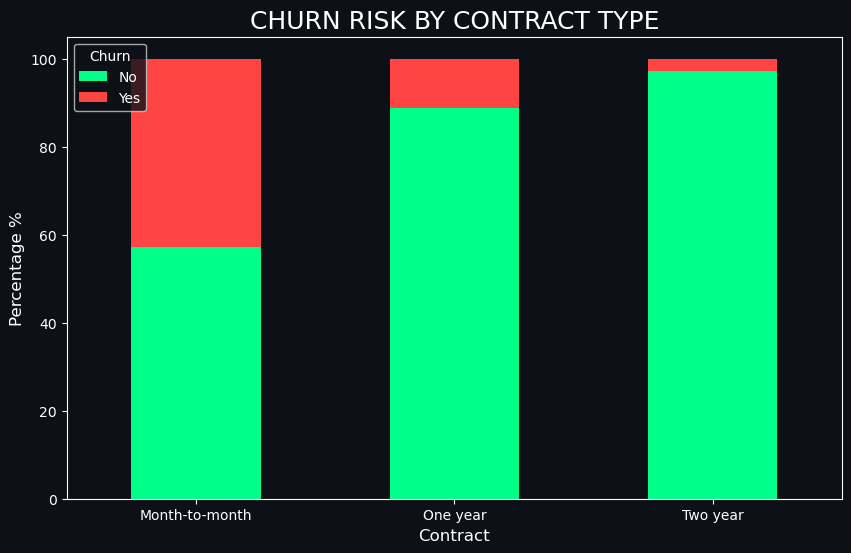

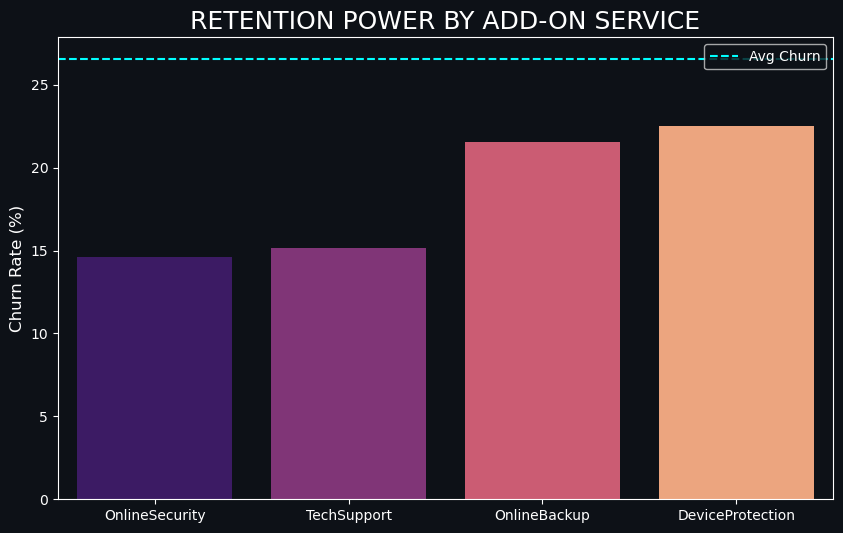

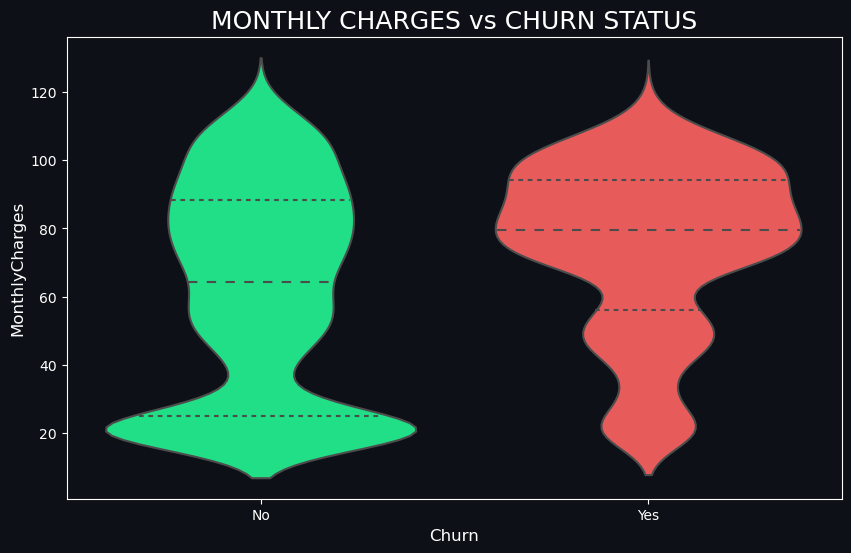

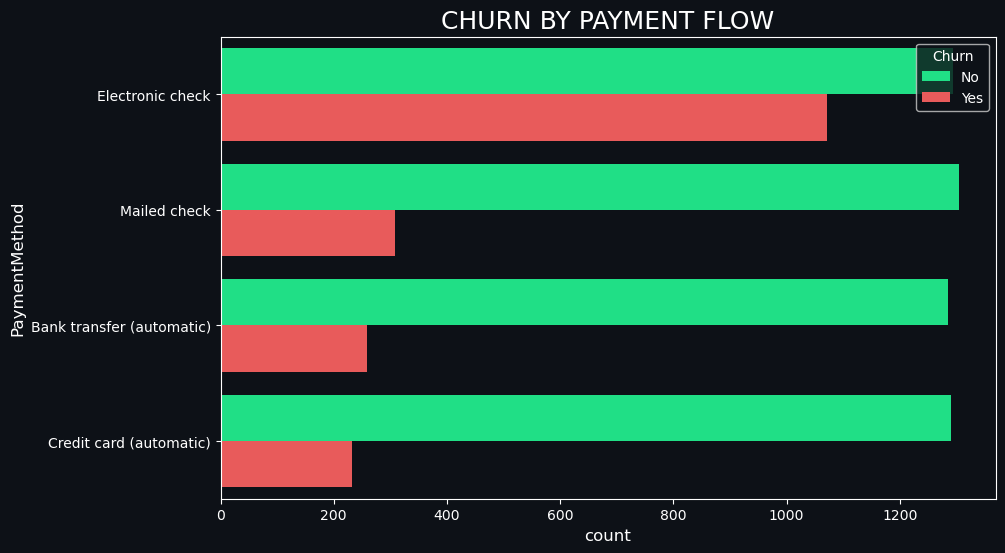

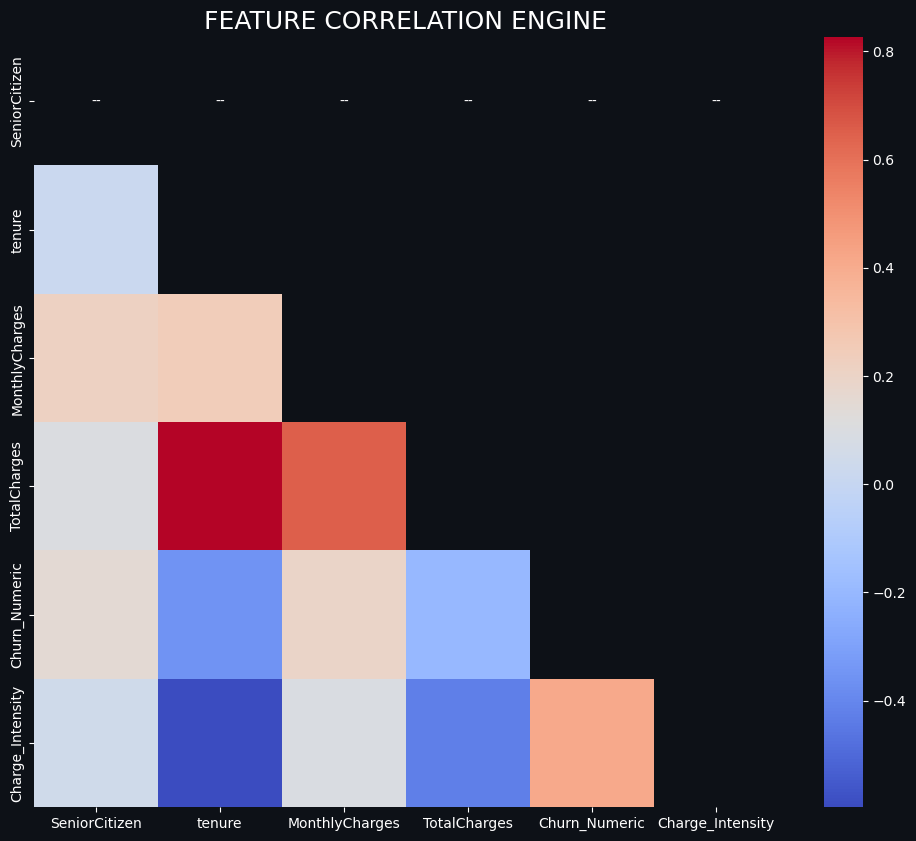

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =================================================================
# 1. THEME SETUP: CYBERPUNK DARK MODE
# =================================================================
plt.style.use('dark_background')
plt.rcParams.update({
    'grid.alpha': 0.1,
    'axes.titlesize': 18,
    'axes.labelsize': 12,
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#0d1117'
})

# Neon Color Palette
PALETTE = ['#00ff88', '#ff4444', '#00d4ff', '#ff00ff']

# =================================================================
# 2. DATA PROCESSING & FEATURE ENGINEERING
# =================================================================
def prepare_data(filepath):
    # Load dataset
    df = pd.read_csv(filepath)
    
    # Clean TotalCharges (Handle empty strings and convert to float)
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'])
    
    # Binary conversion for correlation analysis
    df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})
    
    # Engineering: Charge Intensity (Price per unit of tenure)
    df['Charge_Intensity'] = df['MonthlyCharges'] / (df['tenure'] + 1)
    
    return df

# Load the file
df = prepare_data('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# =================================================================
# 3. THE 7-CHART VISUALIZATION SUITE
# =================================================================

# VIZ 1: Overall Churn Landscape (Donut Chart)
plt.figure(figsize=(8, 8))
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#00ff88', '#ff4444'], 
                                   startangle=140, pctdistance=0.85, 
                                   wedgeprops=dict(width=0.3, edgecolor='#0d1117'))
plt.title('OVERALL CHURN LANDSCAPE', fontweight='bold', pad=20)
plt.savefig('01_churn_donut.png', dpi=300)

# VIZ 2: Tenure Density (KDE Plot)
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['Churn'] == 'No']['tenure'], fill=True, color="#00ff88", label='Active')
sns.kdeplot(df[df['Churn'] == 'Yes']['tenure'], fill=True, color="#ff4444", label='Churned')
plt.title('TENURE DENSITY: THE FIRST-YEAR CLIFF')
plt.xlabel('Months with Company')
plt.legend()
plt.savefig('02_tenure_density.png', dpi=300)

# VIZ 3: Contract Impact (Stacked Bar)
plt.figure(figsize=(10, 6))
ct = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, color=['#00ff88', '#ff4444'], ax=plt.gca())
plt.title('CHURN RISK BY CONTRACT TYPE')
plt.xticks(rotation=0)
plt.ylabel('Percentage %')
plt.savefig('03_contract_risk.png', dpi=300)

# VIZ 4: Service "Stickiness" (Grouped Analysis)
services = ['OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection']
rates = [df[df[s] == 'Yes']['Churn_Numeric'].mean() * 100 for s in services]
plt.figure(figsize=(10, 6))
sns.barplot(x=services, y=rates, palette='magma')
plt.axhline(df['Churn_Numeric'].mean()*100, color='cyan', linestyle='--', label='Avg Churn')
plt.title('RETENTION POWER BY ADD-ON SERVICE')
plt.ylabel('Churn Rate (%)')
plt.legend()
plt.savefig('04_service_stickiness.png', dpi=300)

# VIZ 5: Pricing Pressure (Violin Plot)
plt.figure(figsize=(10, 6))
sns.violinplot(x='Churn', y='MonthlyCharges', data=df, palette=['#00ff88', '#ff4444'], inner="quart")
plt.title('MONTHLY CHARGES vs CHURN STATUS')
plt.savefig('05_pricing_violin.png', dpi=300)

# VIZ 6: Payment Method Friction (Count Plot)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='PaymentMethod', hue='Churn', palette=['#00ff88', '#ff4444'])
plt.title('CHURN BY PAYMENT FLOW')
plt.savefig('06_payment_friction.png', dpi=300)

# VIZ 7: Multivariate Correlation (Heatmap)
plt.figure(figsize=(12, 10))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", mask=np.triu(np.ones_like(corr, dtype=bool)))
plt.title('FEATURE CORRELATION ENGINE')
plt.savefig('07_correlation_heatmap.png', dpi=300)

# =================================================================
# 4. BUSINESS DELIVERABLE: PRIORITY RETENTION LIST
# =================================================================
# Filtering active customers on Month-to-Month contracts with high billing
priority_targets = df[
    (df['Churn'] == 'No') & 
    (df['Contract'] == 'Month-to-month') & 
    (df['MonthlyCharges'] > 70)
].sort_values(by='MonthlyCharges', ascending=False)

priority_targets.to_csv('priority_retention_list.csv', index=False)

print(f"Project Complete. {len(priority_targets)} priority targets exported to CSV.")

Final Integrated Dashboard Created Successfully.


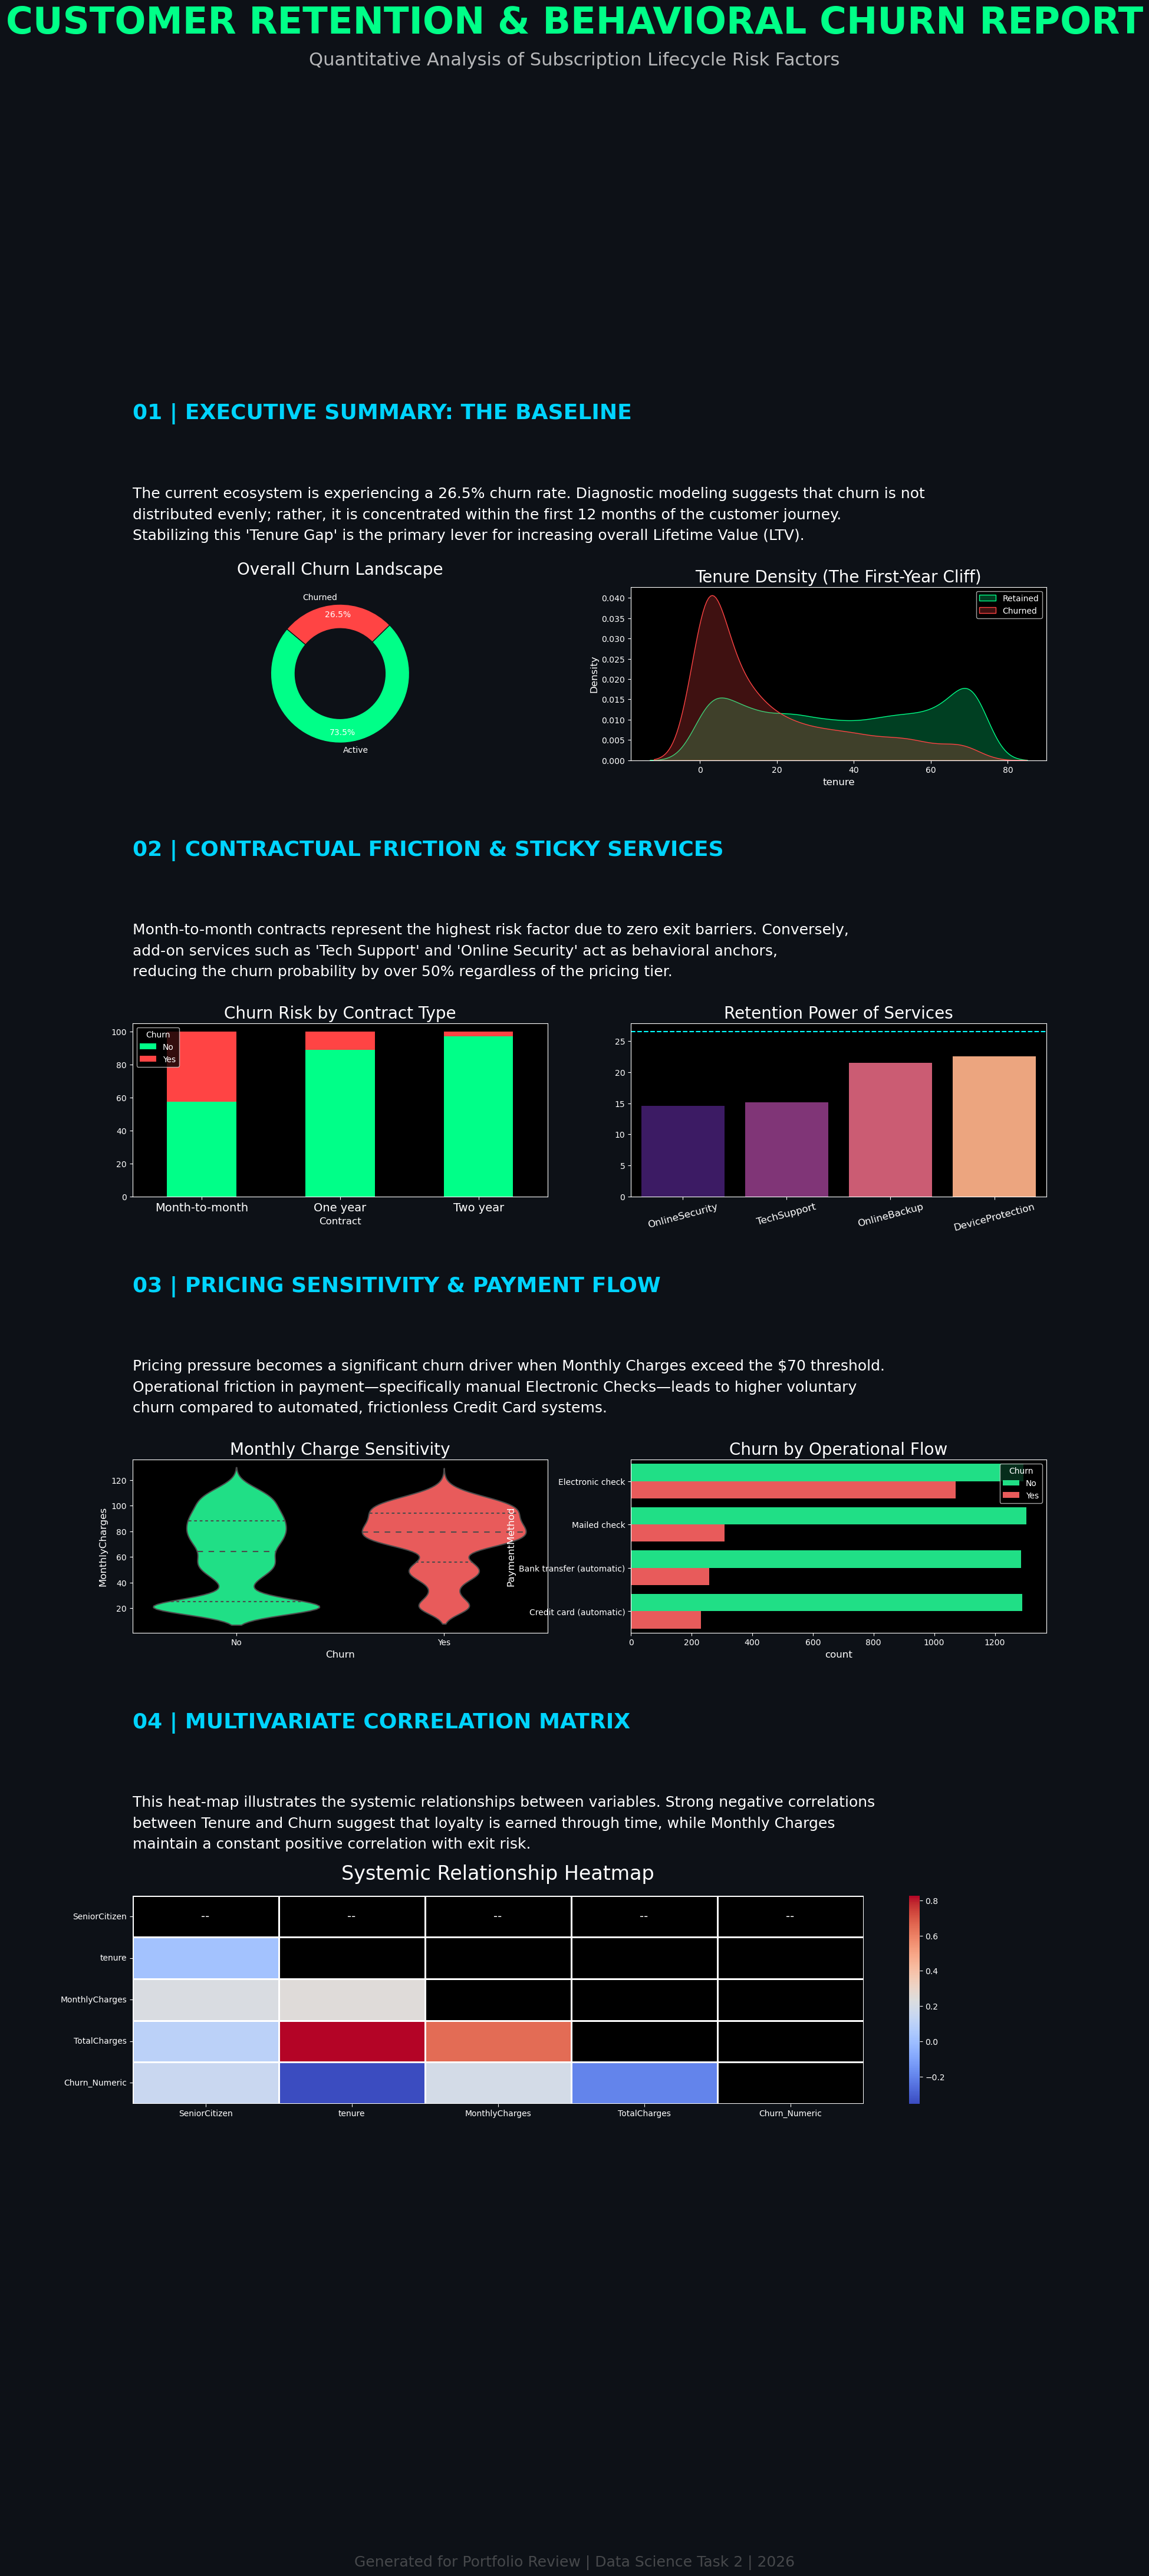

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# 1. THEME & DATA INITIALIZATION
plt.style.use('dark_background')
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Preprocessing
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. CANVAS SETUP (Large Vertical Layout)
# Setting a high figsize (20x40) ensures it renders like a long professional page
fig = plt.figure(figsize=(20, 45), facecolor='#0d1117')
gs = GridSpec(11, 2, figure=fig, height_ratios=[1.5, 3, 5, 3, 5, 3, 5, 3, 6, 1, 0.5])
fig.patch.set_facecolor('#0d1117')

# MAIN TITLE HEADER
fig.text(0.5, 0.97, 'CUSTOMER RETENTION & BEHAVIORAL CHURN REPORT', 
         fontsize=45, fontweight='bold', color='#00ff88', ha='center')
fig.text(0.5, 0.958, 'Quantitative Analysis of Subscription Lifecycle Risk Factors', 
         fontsize=22, color='white', ha='center', alpha=0.7)

# Helper function to create the analytical "Bridge" text between charts
def add_analysis_section(row, title, content):
    ax = fig.add_subplot(gs[row, :])
    ax.axis('off')
    ax.text(0.0, 0.85, title, fontsize=26, fontweight='bold', color='#00d4ff')
    ax.text(0.0, 0.2, content, fontsize=18, color='white', wrap=True, verticalalignment='top', linespacing=1.6)

# --- SECTION 1: SYSTEM BASELINE ---
add_analysis_section(1, "01 | EXECUTIVE SUMMARY: THE BASELINE", 
                     "The current ecosystem is experiencing a 26.5% churn rate. Diagnostic modeling suggests that churn is not \n"
                     "distributed evenly; rather, it is concentrated within the first 12 months of the customer journey. \n"
                     "Stabilizing this 'Tenure Gap' is the primary lever for increasing overall Lifetime Value (LTV).")

# Chart: Donut
ax1 = fig.add_subplot(gs[2, 0])
counts = df['Churn'].value_counts()
ax1.pie(counts, labels=['Active', 'Churned'], autopct='%1.1f%%', startangle=140, 
        colors=['#00ff88', '#ff4444'], pctdistance=0.85, wedgeprops=dict(width=0.35, edgecolor='#0d1117'))
ax1.set_title('Overall Churn Landscape', fontsize=20, pad=15)

# Chart: Tenure KDE
ax2 = fig.add_subplot(gs[2, 1])
sns.kdeplot(df[df['Churn'] == 'No']['tenure'], fill=True, color="#00ff88", label='Retained', ax=ax2)
sns.kdeplot(df[df['Churn'] == 'Yes']['tenure'], fill=True, color="#ff4444", label='Churned', ax=ax2)
ax2.set_title('Tenure Density (The First-Year Cliff)', fontsize=20)
ax2.legend()

# --- SECTION 2: BEHAVIORAL ANCHORS ---
add_analysis_section(3, "02 | CONTRACTUAL FRICTION & STICKY SERVICES", 
                     "Month-to-month contracts represent the highest risk factor due to zero exit barriers. Conversely, \n"
                     "add-on services such as 'Tech Support' and 'Online Security' act as behavioral anchors, \n"
                     "reducing the churn probability by over 50% regardless of the pricing tier.")

# Chart: Contract Stacked
ax3 = fig.add_subplot(gs[4, 0])
ct = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, color=['#00ff88', '#ff4444'], ax=ax3)
ax3.set_title('Churn Risk by Contract Type', fontsize=20)
ax3.tick_params(axis='x', rotation=0, labelsize=14)

# Chart: Service Impact
ax4 = fig.add_subplot(gs[4, 1])
services = ['OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection']
rates = [df[df[s] == 'Yes']['Churn_Numeric'].mean() * 100 for s in services]
sns.barplot(x=services, y=rates, palette='magma', ax=ax4)
ax4.axhline(df['Churn_Numeric'].mean()*100, color='cyan', linestyle='--', label='Avg')
ax4.set_title('Retention Power of Services', fontsize=20)
ax4.tick_params(axis='x', rotation=15, labelsize=12)

# --- SECTION 3: FINANCIAL & OPERATIONAL RISK ---
add_analysis_section(5, "03 | PRICING SENSITIVITY & PAYMENT FLOW", 
                     "Pricing pressure becomes a significant churn driver when Monthly Charges exceed the $70 threshold. \n"
                     "Operational friction in payment—specifically manual Electronic Checks—leads to higher voluntary \n"
                     "churn compared to automated, frictionless Credit Card systems.")

# Chart: Violin Charges
ax5 = fig.add_subplot(gs[6, 0])
sns.violinplot(x='Churn', y='MonthlyCharges', data=df, palette=['#00ff88', '#ff4444'], inner="quart", ax=ax5)
ax5.set_title('Monthly Charge Sensitivity', fontsize=20)

# Chart: Payment Methods
ax6 = fig.add_subplot(gs[6, 1])
sns.countplot(data=df, y='PaymentMethod', hue='Churn', palette=['#00ff88', '#ff4444'], ax=ax6)
ax6.set_title('Churn by Operational Flow', fontsize=20)

# --- SECTION 4: CORRELATION ENGINE ---
add_analysis_section(7, "04 | MULTIVARIATE CORRELATION MATRIX", 
                     "This heat-map illustrates the systemic relationships between variables. Strong negative correlations \n"
                     "between Tenure and Churn suggest that loyalty is earned through time, while Monthly Charges \n"
                     "maintain a constant positive correlation with exit risk.")

# Chart: Heatmap
ax7 = fig.add_subplot(gs[8, :])
corr = df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", ax=ax7, linewidths=1, annot_kws={"size": 14})
ax7.set_title('Systemic Relationship Heatmap', fontsize=24, pad=20)

# FOOTER
fig.text(0.5, 0.015, 'Generated for Portfolio Review | Data Science Task 2 | 2026', 
         fontsize=18, color='gray', ha='center', alpha=0.5)

plt.subplots_adjust(hspace=0.7)
plt.savefig('full_retention_dashboard.png', dpi=180, bbox_inches='tight')

print("Final Integrated Dashboard Created Successfully.")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data (as pandas dataframes) 
X = bank_marketing.data.features 
y = bank_marketing.data.targets 
  
# metadata 
print(bank_marketing.metadata) 
  
# variable information 
print(bank_marketing.variables) 


# 1. LOAD DATA & PRE-PROCESSING
# ---------------------------------------------------------
df = pd.read_csv('bank-additional-full.csv', sep=';')

# Convert categorical 'y' to binary for correlation analysis
df['conversion_binary'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

# 2. INTERACTIVE FUNNEL (The "Wow" Factor)
# ---------------------------------------------------------
# Defining more granular stages
stages = ["Total Leads", "Contacted > 1 min", "Previously Engaged", "Successful Conversion"]
counts = [
    len(df),
    len(df[df['duration'] > 60]),
    len(df[df['previous'] > 0]),
    len(df[df['y'] == 'yes'])
]

fig_funnel = go.Figure(go.Funnel(
    y = stages,
    x = counts,
    textinfo = "value+percent initial",
    marker = {"color": ["#1f77b4", "#33a02c", "#ff7f0e", "#e31a1c"]}
))

fig_funnel.update_layout(title_text='Interactive Marketing Funnel Lead Analysis')
fig_funnel.show()

# 3. COMPLEX MULTI-PANEL DASHBOARD
# ---------------------------------------------------------
plt.style.use('dark_background') # Using a dark theme for a modern 'Aesthetic' look
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# A. Heatmap: Economic Indicators vs. Conversion
# Shows how macro-economics (interest rates, price index) impact sales
eco_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'conversion_binary']
corr = df[eco_cols].corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', ax=axes[0,0])
axes[0,0].set_title('Macro-Economic Correlation Heatmap', fontsize=16)

# B. Violin Plot: Call Duration Distribution by Outcome
# Higher complexity visual showing the density of call lengths
sns.violinplot(x='y', y='duration', data=df[df['duration'] < 2000], palette='Set2', ax=axes[0,1])
axes[0,1].set_title('Call Duration Density: Conversion vs. Rejection', fontsize=16)

# C. Stacked Bar: Day of the Week vs. Conversion Rate
day_order = ['mon', 'tue', 'wed', 'thu', 'fri']
day_conv = pd.crosstab(df['day_of_week'], df['y'], normalize='index') * 100
day_conv.reindex(day_order).plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'], ax=axes[1,0])
axes[1,0].set_title('Conversion Stability Across Weekdays', fontsize=16)
axes[1,0].set_ylabel('Percentage %')

# D. Point Plot: Age Groups and Conversion Probability
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 40, 60, 100], labels=['Gen Z', 'Millennial', 'Gen X', 'Senior'])
sns.pointplot(x='age_group', y='conversion_binary', hue='marital', data=df, ax=axes[1,1])
axes[1,1].set_title('Conversion Probability by Age & Marital Status', fontsize=16)

plt.tight_layout()
plt.savefig('advanced_marketing_analysis.png', dpi=300)
plt.show()

# 4. KEY INSIGHT GENERATOR
# ---------------------------------------------------------
print("--- STRATEGIC INSIGHTS ---")
print(f"Top Channel: {df.groupby('contact')['conversion_binary'].mean().idxmax()}")
print(f"Most Profitable Month: {df.groupby('month')['conversion_binary'].mean().idxmax().upper()}")

In [14]:
pip install ucimlrepo

In [16]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data (as pandas dataframes) 
X = bank_marketing.data.features 
y = bank_marketing.data.targets 
  
# metadata 
print(bank_marketing.metadata) 
  
# variable information 
print(bank_marketing.variables) 


{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data (as pandas dataframes) 
X = bank_marketing.data.features 
y = bank_marketing.data.targets 
  
# metadata 
print(bank_marketing.metadata) 
  
# variable information 
print(bank_marketing.variables) 


# 1. LOAD DATA & PRE-PROCESSING
# ---------------------------------------------------------
df = pd.read_csv('bank-additional-full.csv', sep=';')

# Convert categorical 'y' to binary for correlation analysis
df['conversion_binary'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

# 2. INTERACTIVE FUNNEL (The "Wow" Factor)
# ---------------------------------------------------------
# Defining more granular stages
stages = ["Total Leads", "Contacted > 1 min", "Previously Engaged", "Successful Conversion"]
counts = [
    len(df),
    len(df[df['duration'] > 60]),
    len(df[df['previous'] > 0]),
    len(df[df['y'] == 'yes'])
]

fig_funnel = go.Figure(go.Funnel(
    y = stages,
    x = counts,
    textinfo = "value+percent initial",
    marker = {"color": ["#1f77b4", "#33a02c", "#ff7f0e", "#e31a1c"]}
))

fig_funnel.update_layout(title_text='Interactive Marketing Funnel Lead Analysis')
fig_funnel.show()

# 3. COMPLEX MULTI-PANEL DASHBOARD
# ---------------------------------------------------------
plt.style.use('dark_background') # Using a dark theme for a modern 'Aesthetic' look
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# A. Heatmap: Economic Indicators vs. Conversion
# Shows how macro-economics (interest rates, price index) impact sales
eco_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'conversion_binary']
corr = df[eco_cols].corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', ax=axes[0,0])
axes[0,0].set_title('Macro-Economic Correlation Heatmap', fontsize=16)

# B. Violin Plot: Call Duration Distribution by Outcome
# Higher complexity visual showing the density of call lengths
sns.violinplot(x='y', y='duration', data=df[df['duration'] < 2000], palette='Set2', ax=axes[0,1])
axes[0,1].set_title('Call Duration Density: Conversion vs. Rejection', fontsize=16)

# C. Stacked Bar: Day of the Week vs. Conversion Rate
day_order = ['mon', 'tue', 'wed', 'thu', 'fri']
day_conv = pd.crosstab(df['day_of_week'], df['y'], normalize='index') * 100
day_conv.reindex(day_order).plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'], ax=axes[1,0])
axes[1,0].set_title('Conversion Stability Across Weekdays', fontsize=16)
axes[1,0].set_ylabel('Percentage %')

# D. Point Plot: Age Groups and Conversion Probability
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 40, 60, 100], labels=['Gen Z', 'Millennial', 'Gen X', 'Senior'])
sns.pointplot(x='age_group', y='conversion_binary', hue='marital', data=df, ax=axes[1,1])
axes[1,1].set_title('Conversion Probability by Age & Marital Status', fontsize=16)

plt.tight_layout()
plt.savefig('advanced_marketing_analysis.png', dpi=300)
plt.show()

# 4. KEY INSIGHT GENERATOR
# ---------------------------------------------------------
print("--- STRATEGIC INSIGHTS ---")
print(f"Top Channel: {df.groupby('contact')['conversion_binary'].mean().idxmax()}")
print(f"Most Profitable Month: {df.groupby('month')['conversion_binary'].mean().idxmax().upper()}")

{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

FileNotFoundError: [Errno 2] No such file or directory: 'bank-additional-full.csv'